<a href="https://colab.research.google.com/github/7amzaGH/Underwater-Pipeline-Geometric-Perception/blob/main/notebooks/Pipeline__Geometric_Perception_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Underwater Pipeline Geometric Perception - Demo Notebook**
**Repository:** [Underwater-Pipeline-Geometric-Perception](https://github.com/7amzaGH/Underwater-Pipeline-Geometric-Perception)

This notebook demonstrates a lightweight underwater pipeline perception framework for extracting navigation-relevant geometric information from monocular underwater imagery using YOLOv8n instance segmentation and PCA-based geometric estimation.

The framework is designed for:

- embedded AI deployment
- underwater robotic inspection
- real-time pipeline perception
- deployment-oriented segmentation inference

### Pipeline Overview

1. **Setup** — Clone repository and install dependencies  
2. **Dataset** — Download the external underwater evaluation dataset from Roboflow  
3. **Inference** — Run YOLOv8n-seg pipeline detection on underwater frames  
4. **Geometry Extraction** — Estimate pipeline center alignment and dominant orientation using PCA  
5. **Evaluation** — Compute center error, orientation error, and direction consistency metrics  
6. **Visualization** — Generate plots and quantitative geometry analysis results

### Perception Outputs

The proposed framework extracts:

- **Pipeline Center Position** — image-plane horizontal alignment
- **Lateral Offset** — displacement from image center
- **Pipeline Orientation** — dominant angular direction
- **Navigation Command** — LEFT / STRAIGHT / RIGHT directional cue


In [ ]:
# 1. Clone GitHub Repository
!git clone https://github.com/7amzaGH/Underwater-Pipeline-Geometric-Perception.git

# 2. Change directory into the repo
%cd Underwater-Pipeline-Geometric-Perception

In [2]:
# 3. Install Requirements

!pip install -q -r requirements.txt
!pip install -q roboflow pandas matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.1 MB/s eta 0:00:00


In [3]:
# 4. Download External Test Set: Underwater Pipeline Hibbard from Roboflow

from roboflow import Roboflow
import os

# IMPORTANT:
# In Colab, add your Roboflow API key here.
# You can get it from Roboflow > Settings > API.
ROBOFLOW_API_KEY = "YOUR_ROBOFLOW_API_KEY"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("hamzaghitri").project("underwater-pipeline-hibbard")
version = project.version(2)

dataset = version.download("yolov8")

DATASET_DIR = dataset.location

print("Dataset downloaded to:", DATASET_DIR)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Underwater-pipeline-hibbard-2 in yolov8:: 100%|██████████| 403/403 [00:00<00:00, 6279.50it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset downloaded to: /content/Underwater-Pipeline-Geometric-Perception/Underwater-pipeline-hibbard-2


In [5]:
# 5. Load Model and Source Files

import os
import glob
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from src.detect import PTDetector, get_best_detection
from src.geometry import estimate_pipeline_geometry, compute_geometry_error

MODEL_PATH = "models/best.pt"

IMAGE_DIR = os.path.join(DATASET_DIR, "test", "images")
LABEL_DIR = os.path.join(DATASET_DIR, "test", "labels")

image_paths = sorted(
    glob.glob(os.path.join(IMAGE_DIR, "*.jpg")) +
    glob.glob(os.path.join(IMAGE_DIR, "*.png")) +
    glob.glob(os.path.join(IMAGE_DIR, "*.jpeg"))
)

print("Number of test images:", len(image_paths))

detector = PTDetector(MODEL_PATH, conf_threshold=0.5)

Number of test images: 200


In [6]:
# 6. YOLO Polygon Label -> Binary Mask
# Roboflow YOLOv8 segmentation labels:
# class x1 y1 x2 y2 x3 y3 ...
# normalized coordinates

def load_yolo_seg_mask(label_path, image_shape):
    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    if not os.path.exists(label_path):
        return mask

    with open(label_path, "r") as f:
        lines = f.readlines()

    for line in lines:
        values = line.strip().split()

        if len(values) < 7:
            continue

        coords = np.array(values[1:], dtype=np.float32)

        xs = coords[0::2] * w
        ys = coords[1::2] * h

        polygon = np.stack([xs, ys], axis=1).astype(np.int32)

        cv2.fillPoly(mask, [polygon], 1)

    return mask

In [7]:
# 7. Evaluate Model + Geometry on Dataset Frames

rows = []

for image_path in tqdm(image_paths, desc="Evaluating frames"):

    frame = cv2.imread(image_path)

    if frame is None:
        continue

    h, w = frame.shape[:2]

    image_name = os.path.basename(image_path)
    label_name = os.path.splitext(image_name)[0] + ".txt"
    label_path = os.path.join(LABEL_DIR, label_name)

    # Ground-truth mask from Roboflow polygon label
    gt_mask = load_yolo_seg_mask(label_path, frame.shape)
    gt_geometry = estimate_pipeline_geometry(gt_mask)

    # Prediction
    detections = detector.detect(frame)
    best = get_best_detection(detections)

    if best is None:
        pred_geometry = estimate_pipeline_geometry(None, angle_threshold=5.0)
        geometry_error = {
            "valid": False,
            "center_error_px": None,
            "angle_error_deg": None,
            "direction_match": False,
        }

        rows.append({
            "image": image_name,
            "detected": False,
            "conf": 0.0,
            "gt_valid": gt_geometry["valid"],
            "pred_valid": pred_geometry["valid"],
            "gt_center_x": gt_geometry["center_x"],
            "pred_center_x": pred_geometry["center_x"],
            "center_error_px": None,
            "gt_angle_deg": gt_geometry["angle_deg"],
            "pred_angle_deg": pred_geometry["angle_deg"],
            "angle_error_deg": None,
            "gt_direction": gt_geometry["direction"],
            "pred_direction": pred_geometry["direction"],
            "direction_match": False,
        })

        continue

    pred_mask = best["mask"]
    pred_geometry = estimate_pipeline_geometry(pred_mask)

    geometry_error = compute_geometry_error(pred_geometry, gt_geometry)

    rows.append({
        "image": image_name,
        "detected": True,
        "conf": best["conf"],

        "gt_valid": gt_geometry["valid"],
        "pred_valid": pred_geometry["valid"],

        "gt_center_x": gt_geometry["center_x"],
        "pred_center_x": pred_geometry["center_x"],
        "center_error_px": geometry_error["center_error_px"],

        "gt_angle_deg": gt_geometry["angle_deg"],
        "pred_angle_deg": pred_geometry["angle_deg"],
        "angle_error_deg": geometry_error["angle_error_deg"],

        "gt_direction": gt_geometry["direction"],
        "pred_direction": pred_geometry["direction"],
        "direction_match": geometry_error["direction_match"],
    })

df = pd.DataFrame(rows)

os.makedirs("outputs", exist_ok=True)
df.to_csv("outputs/hibbard_frame_geometry_eval.csv", index=False)

display(df.head())
print("Saved:", "outputs/hibbard_frame_geometry_eval.csv")

Evaluating frames: 100%|██████████| 200/200 [00:38<00:00,  5.18it/s]


,image,detected,conf,gt_valid,pred_valid,gt_center_x,pred_center_x,center_error_px,gt_angle_deg,pred_angle_deg,angle_error_deg,gt_direction,pred_direction,direction_match
0,frame_0001_png.rf.753ad52a9448608ee19210fedc81...,True,0.9146,True,True,433.876434,436.676300,4.449627,-14.762011,-15.133595,0.371584,LEFT,LEFT,True
1,frame_0002_png.rf.ee3aa585dd9d08680d1c093f4952...,True,0.8982,False,True,320.000000,475.609497,NaN,0.000000,-16.239665,NaN,STRAIGHT,LEFT,False
2,frame_0004_png.rf.29ae2211bf2fe4521290082bb06a...,True,0.8759,True,True,482.899200,500.240906,79.270800,-20.668746,-17.287788,3.380958,LEFT,LEFT,True
3,frame_0005_png.rf.2f8de0fc06c1198fe34c73039d13...,True,0.9200,True,True,481.279236,502.404938,68.377988,-22.765155,-20.423660,2.341495,LEFT,LEFT,True
4,frame_0006_png.rf.ad1a2d77ea4ba386c693f79875c2...,True,0.9269,True,True,476.048126,477.391235,7.387764,-21.020777,-22.226860,1.206083,LEFT,LEFT,True


Saved: outputs/hibbard_frame_geometry_eval.csv


In [8]:
# 8. Print Geometry Evaluation Summary


valid_df = df[
    (df["detected"] == True) &
    (df["gt_valid"] == True) &
    (df["pred_valid"] == True)
].copy()

total = len(df)
detected = df["detected"].sum()
valid = len(valid_df)

print("========== Detection Summary ==========")
print(f"Total frames:          {total}")
print(f"Detected frames:       {detected}")
print(f"Detection rate:        {detected / total:.3f}")
print(f"Valid geometry frames: {valid}")
print(f"Valid geometry rate:   {valid / total:.3f}")

print("\n========== Geometry Accuracy ==========")
print(f"Mean center error:     {valid_df['center_error_px'].mean():.3f} px")
print(f"Std center error:      {valid_df['center_error_px'].std():.3f} px")
print(f"Mean angle error:      {valid_df['angle_error_deg'].mean():.3f} deg")
print(f"Std angle error:       {valid_df['angle_error_deg'].std():.3f} deg")

print("\n========== Threshold Metrics ==========")
print(f"Center error < 10 px:  {(valid_df['center_error_px'] < 10).mean() * 100:.2f}%")
print(f"Angle error < 5 deg:   {(valid_df['angle_error_deg'] < 5).mean() * 100:.2f}%")
print(f"Direction accuracy:    {valid_df['direction_match'].mean() * 100:.2f}%")

========== Detection Summary ==========
Total frames:          200
Detected frames:       200
Detection rate:        1.000
Valid geometry frames: 199
Valid geometry rate:   0.995

========== Geometry Accuracy ==========
Mean center error:     5.871 px
Std center error:      8.181 px
Mean angle error:      0.554 deg
Std angle error:       0.563 deg

========== Threshold Metrics ==========
Center error < 10 px:  90.45%
Angle error < 5 deg:   100.00%
Direction accuracy:    97.49%


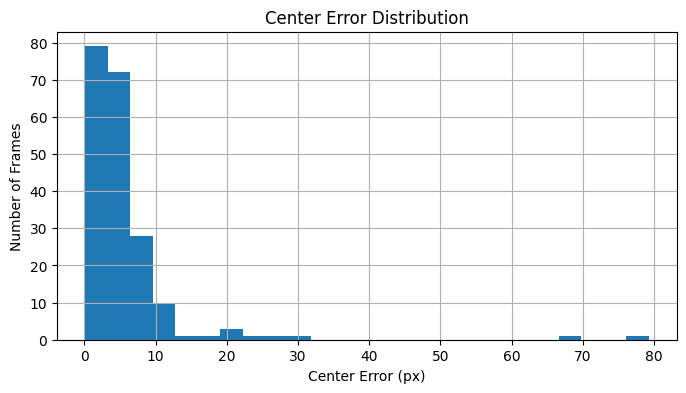

In [9]:
# 9. Plot Center Error Distribution


plt.figure(figsize=(8, 4))
plt.hist(valid_df["center_error_px"], bins=25)
plt.title("Center Error Distribution")
plt.xlabel("Center Error (px)")
plt.ylabel("Number of Frames")
plt.grid(True)
plt.show()

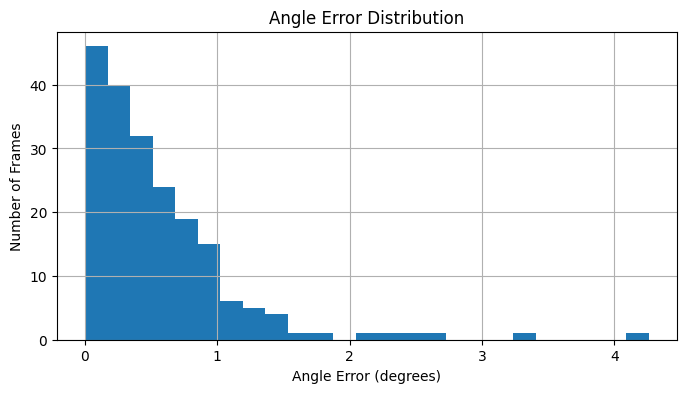

In [10]:
# 10. Plot Angle Error Distribution


plt.figure(figsize=(8, 4))
plt.hist(valid_df["angle_error_deg"], bins=25)
plt.title("Angle Error Distribution")
plt.xlabel("Angle Error (degrees)")
plt.ylabel("Number of Frames")
plt.grid(True)
plt.show()

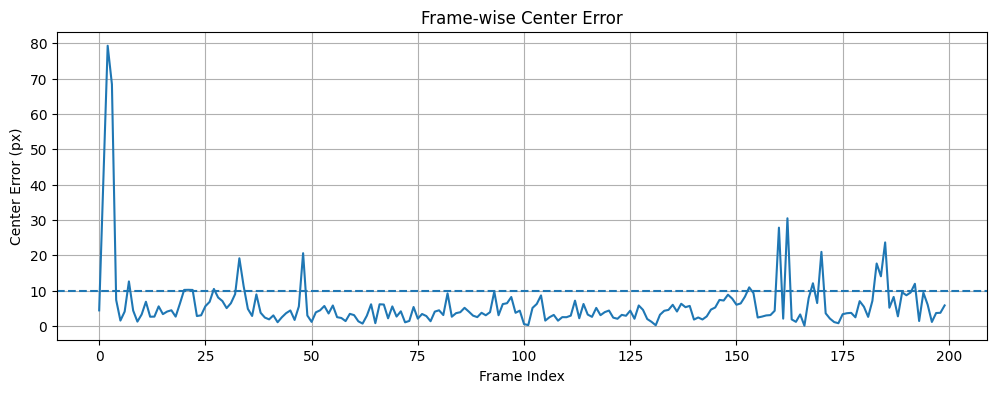

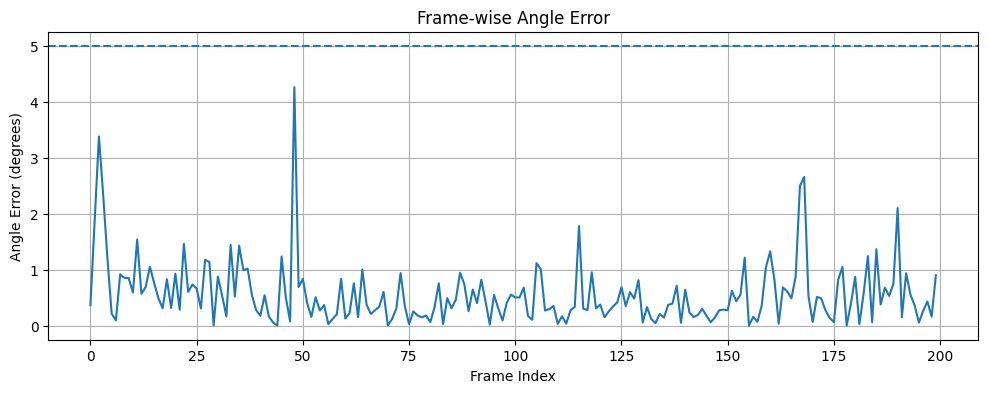

In [11]:
# 11. Plot Frame-wise Errors


plt.figure(figsize=(12, 4))
plt.plot(valid_df.index, valid_df["center_error_px"])
plt.axhline(10, linestyle="--")
plt.title("Frame-wise Center Error")
plt.xlabel("Frame Index")
plt.ylabel("Center Error (px)")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(valid_df.index, valid_df["angle_error_deg"])
plt.axhline(5, linestyle="--")
plt.title("Frame-wise Angle Error")
plt.xlabel("Frame Index")
plt.ylabel("Angle Error (degrees)")
plt.grid(True)
plt.show()

In [12]:
# 12. Direction Confusion Table


confusion = pd.crosstab(
    valid_df["gt_direction"],
    valid_df["pred_direction"],
    rownames=["Ground Truth"],
    colnames=["Prediction"]
)

display(confusion)

Prediction,LEFT,RIGHT,STRAIGHT
Ground Truth,,,
LEFT,86,0,1
RIGHT,0,41,1
STRAIGHT,0,3,67
